In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# LOAD DATA
datar = np.loadtxt("2mmR.dat", delimiter=",")
datas = np.loadtxt("2mmS.dat", delimiter=",")
ts = datas[:, 0]
tr = datar[:, 0]
sr = datar[:, 1]
ss = datas[:, 1]

# INTERPOLATION
startt = 0
endt = 4.6116e-11
dt = min(np.mean(np.diff(ts)), np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT
fftr = np.fft.fft(sr, 16384)
ffts = np.fft.fft(ss, 16384)
freq = np.fft.fftfreq(16384, dt)

# MASK
mask = (freq > 0) & (freq < 3e12)
fftr = fftr[mask]
ffts = ffts[mask]
freq = freq[mask]

# TRANSFER FUNCTION
tf_exp = ffts / fftr

L = 2e-3
c = 3e8


freq_t = torch.tensor(freq, dtype=torch.float32)
H_exp_t = torch.tensor(tf_exp, dtype=torch.complex64)


n_results = []
k_results = []
loss_results = []

def H_th_scalar(n, k, f):
    n_complex = n + 1j * k
    n0 = 1.0
    omega = 2 * torch.pi * f

    r01 = (n_complex - n0) / (n_complex + n0)
    t01 = (4 * n_complex * n0) / ((n_complex + n0) ** 2)

    phase_term = torch.exp(-1j * omega * L * (n_complex - n0) / c)
    denom = 1 - (r01 ** 2) * torch.exp(-2j * omega * n_complex * L / c)

    return t01 * phase_term / denom


def loss_scalar(n, k, f, H_exp):
    H_theo = H_th_scalar(n, k, f)
    return (torch.real(H_theo - H_exp) ** 2 + torch.imag(H_theo - H_exp) ** 2)


def optimize_one(f, H_exp, n_init, k_init, lr=1e-3, steps=500):
    n = torch.tensor(n_init.item(), dtype=torch.float32, requires_grad=True)
    k = torch.tensor(k_init.item(), dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.Adam([n, k], lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_scalar(n, k, f, H_exp)
        loss.backward()
        optimizer.step()
    return n.detach(), k.detach(), loss.item()


n_guess = torch.tensor(2.0, dtype=torch.float32)
k_guess = torch.tensor(0.005, dtype=torch.float32)

for i in range(len(freq)):
    f = freq_t[i]
    H_exp = H_exp_t[i]
    n_opt, k_opt, loss_val = optimize_one(f, H_exp, n_guess, k_guess)

    n_results.append(n_opt.item())
    k_results.append(k_opt.item())
    loss_results.append(loss_val)

  
    n_guess = n_opt.clone().detach()
    k_guess = k_opt.clone().detach()

    


n_results = np.array(n_results)
k_results = np.array(k_results)




[1/950] f = 0.003 THz | n = 1.54257, k = -0.45758, loss = 3.67e+02
[2/950] f = 0.006 THz | n = 1.07449, k = -0.93086, loss = 3.97e+01
[3/950] f = 0.009 THz | n = 0.56227, k = -1.42759, loss = 4.88e+00
[4/950] f = 0.013 THz | n = 0.04556, k = -1.87555, loss = 1.03e-01
[5/950] f = 0.016 THz | n = 0.47453, k = -1.34856, loss = 7.36e-02
[6/950] f = 0.019 THz | n = 0.92230, k = -0.85797, loss = 1.77e-01
[7/950] f = 0.022 THz | n = 1.38775, k = -0.35822, loss = 1.14e-01
[8/950] f = 0.025 THz | n = 1.75994, k = 0.02950, loss = 1.07e-02
[9/950] f = 0.028 THz | n = 1.97915, k = 0.06464, loss = 4.31e-06
[10/950] f = 0.032 THz | n = 1.99824, k = 0.01001, loss = 3.55e-15
[11/950] f = 0.035 THz | n = 1.98579, k = -0.02146, loss = 2.00e-15
[12/950] f = 0.038 THz | n = 1.96821, k = -0.03473, loss = 2.57e-14
[13/950] f = 0.041 THz | n = 1.95241, k = -0.03659, loss = 1.78e-14
[14/950] f = 0.044 THz | n = 1.94031, k = -0.03160, loss = 1.78e-14
[15/950] f = 0.047 THz | n = 1.93204, k = -0.02264, loss = 0

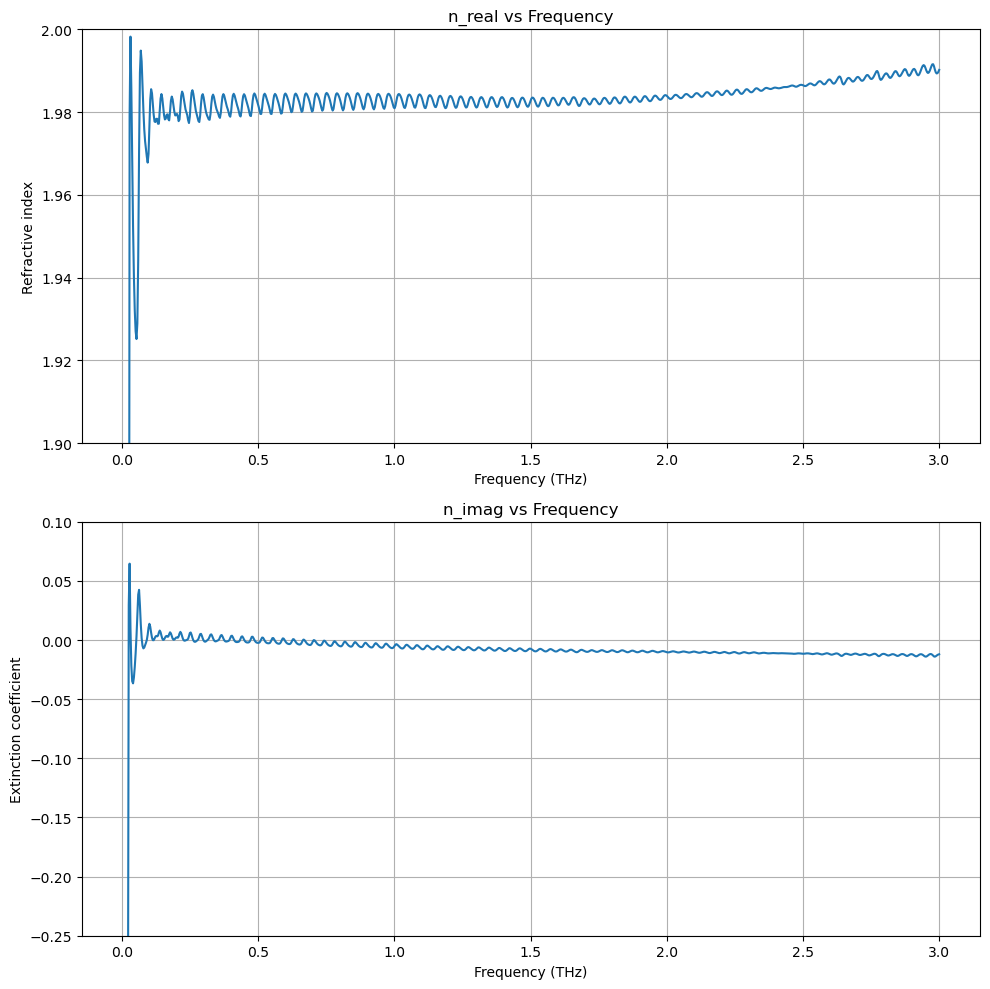

In [11]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(freq * 1e-12, n_results)
plt.xlabel("Frequency (THz)")
plt.ylabel("Refractive index")
plt.title("n_real vs Frequency")
plt.ylim(1.9, 2.0)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freq * 1e-12, k_results)
plt.xlabel("Frequency (THz)")
plt.ylabel("Extinction coefficient")
plt.title("n_imag vs Frequency")
plt.ylim(-0.25, 0.1)

plt.grid(True)

plt.tight_layout()
plt.show()
